In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

X = np.load("../data/processed/combined_data.npy")
y = np.load("../data/processed/combined_labels.npy")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape, len(y_train))
print(X_test.shape, len(y_test))

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

# fit only on train

X_test_scaled = scaler.transform(X_test)

# apply same scaling to test

In [ ]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

In [ ]:
!pip install tensorflow

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [ ]:
input_dim = X_train_scaled.shape[1]

# input layer
input_layer = Input(shape=(input_dim,))

# encoder
encoded = Dense(256, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)

# bottleneck (64)
bottleneck = Dense(64, activation='relu')(encoded)

# decoder
decoded = Dense(64, activation='relu')(bottleneck)
decoded = Dense(256, activation='relu')(decoded)

# output layer
output_layer = Dense(input_dim, activation='linear')(decoded)

# model
autoencoder = Model(inputs=input_layer, outputs=output_layer)

In [ ]:
autoencoder.summary()

In [ ]:
autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

In [ ]:
history = autoencoder.fit(
    X_train_scaled,
    X_train_scaled,
    epochs=20,
    batch_size=128,
    validation_data=(X_test_scaled, X_test_scaled),
    verbose=1
)

In [ ]:
encoder = Model(inputs=input_layer, outputs=bottleneck)

In [ ]:
encoder.summary()

In [ ]:
X_train_encoded = encoder.predict(X_train_scaled)
X_test_encoded = encoder.predict(X_test_scaled)

In [ ]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

In [ ]:
np.save("../data/processed/GE_train_encoded.npy", X_train_encoded)
np.save("../data/processed/GE_test_encoded.npy", X_test_encoded)

np.save("../data/processed/GE_train_labels.npy", y_train)
np.save("../data/processed/GE_test_labels.npy", y_test)

In [ ]:
X_check = np.load("../data/processed/GE_train_encoded.npy")
print(X_check.shape)

In [ ]:
import numpy as np

X_dm = np.load("../data/processed/GSE80970_data.npy")
y_dm = np.load("../data/processed/GSE80970_labels.npy")

print(X_dm.shape, len(y_dm))

In [ ]:
from sklearn.model_selection import train_test_split

X_dm_train, X_dm_test, y_dm_train, y_dm_test = train_test_split(
    X_dm,
    y_dm,
    test_size=0.3,
    random_state=42,
    stratify=y_dm
)

In [ ]:
print(X_dm_train.shape, len(y_dm_train))
print(X_dm_test.shape, len(y_dm_test))

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_dm = StandardScaler()

X_dm_train_scaled = scaler_dm.fit_transform(X_dm_train)

X_dm_test_scaled = scaler_dm.transform(X_dm_test)

In [ ]:
print(X_dm_train_scaled.shape)
print(X_dm_test_scaled.shape)

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim_dm = X_dm_train_scaled.shape[1]

input_layer_dm = Input(shape=(input_dim_dm,))

# encoder (smaller)
encoded_dm = Dense(128, activation='relu')(input_layer_dm)
encoded_dm = Dense(32, activation='relu')(encoded_dm)

# bottleneck
bottleneck_dm = Dense(32, activation='relu')(encoded_dm)

# decoder
decoded_dm = Dense(32, activation='relu')(bottleneck_dm)
decoded_dm = Dense(128, activation='relu')(decoded_dm)

output_layer_dm = Dense(input_dim_dm, activation='linear')(decoded_dm)

# model
autoencoder_dm = Model(inputs=input_layer_dm, outputs=output_layer_dm)

In [ ]:
autoencoder_dm.summary()

In [ ]:
input_layer_dm = Input(shape=(input_dim_dm,))

# MUCH smaller encoder
encoded_dm = Dense(32, activation='relu')(input_layer_dm)

# bottleneck
bottleneck_dm = Dense(16, activation='relu')(encoded_dm)

# decoder
decoded_dm = Dense(32, activation='relu')(bottleneck_dm)

output_layer_dm = Dense(input_dim_dm, activation='linear')(decoded_dm)

autoencoder_dm = Model(inputs=input_layer_dm, outputs=output_layer_dm)

In [ ]:
autoencoder_dm.summary()

In [ ]:
autoencoder_dm.compile(
    optimizer='adam',
    loss='mse'
)

In [ ]:
history_dm = autoencoder_dm.fit(
    X_dm_train_scaled,
    X_dm_train_scaled,
    epochs=10,
    batch_size=32,
    validation_data=(X_dm_test_scaled, X_dm_test_scaled),
    verbose=1
)

In [ ]:
encoder_dm = Model(inputs=input_layer_dm, outputs=bottleneck_dm)

In [ ]:
encoder_dm.summary()

In [ ]:
X_dm_train_encoded = encoder_dm.predict(X_dm_train_scaled)
X_dm_test_encoded = encoder_dm.predict(X_dm_test_scaled)

In [ ]:
print(X_dm_train_encoded.shape)
print(X_dm_test_encoded.shape)

In [ ]:
np.save("../data/processed/DM_train_encoded.npy", X_dm_train_encoded)
np.save("../data/processed/DM_test_encoded.npy", X_dm_test_encoded)

np.save("../data/processed/DM_train_labels.npy", y_dm_train)
np.save("../data/processed/DM_test_labels.npy", y_dm_test)

In [ ]:
X_check = np.load("../data/processed/DM_train_encoded.npy")
print(X_check.shape)

In [ ]:
import numpy as np

# GE
X_ge_train = np.load("../data/processed/GE_train_encoded.npy")
y_ge_train = np.load("../data/processed/GE_train_labels.npy")

# DM
X_dm_train = np.load("../data/processed/DM_train_encoded.npy")
y_dm_train = np.load("../data/processed/DM_train_labels.npy")

print(X_ge_train.shape, len(y_ge_train))
print(X_dm_train.shape, len(y_dm_train))

In [ ]:
X_combined = []
y_combined = []

for i in range(len(X_ge_train)):
    for j in range(len(X_dm_train)):
        
        # pair only if labels match
        if y_ge_train[i] == y_dm_train[j]:
            
            combined = np.concatenate((X_ge_train[i], X_dm_train[j]))
            
            X_combined.append(combined)
            y_combined.append(y_ge_train[i])

In [ ]:
X_combined = np.array(X_combined)
y_combined = np.array(y_combined)

In [ ]:
print(X_combined.shape)
print(len(y_combined))

In [ ]:
np.save("../data/processed/X_combined.npy", X_combined)
np.save("../data/processed/y_combined.npy", y_combined)

In [ ]:
X_check = np.load("../data/processed/X_combined.npy")
print(X_check.shape)

In [ ]:
from sklearn.model_selection import train_test_split

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_combined,
    y_combined,
    test_size=0.3,
    random_state=42,
    stratify=y_combined
)

In [ ]:
print(X_train_final.shape)
print(X_test_final.shape)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# model
lr = LogisticRegression(
    max_iter=3000,
    solver='saga'
)

# train
lr.fit(X_train_final, y_train_final)

# predict
y_pred_lr = lr.predict(X_test_final)

# evaluate
print("Accuracy:", accuracy_score(y_test_final, y_pred_lr))
print(classification_report(y_test_final, y_pred_lr))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train_final, y_train_final)

y_pred_rf = rf.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test_final, y_pred_rf))
print(classification_report(y_test_final, y_pred_rf))

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')

svm.fit(X_train_final, y_train_final)

y_pred_svm = svm.predict(X_test_final)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test_final, y_pred_svm))
print(classification_report(y_test_final, y_pred_svm))

In [ ]:
# NOTE:
# Previous pairing caused data leakage because train-test split was done after pairing.
# This section corrects the approach by pairing train and test sets separately.

In [ ]:
import numpy as np

# GE
X_ge_train = np.load("../data/processed/GE_train_encoded.npy")
y_ge_train = np.load("../data/processed/GE_train_labels.npy")

X_ge_test = np.load("../data/processed/GE_test_encoded.npy")
y_ge_test = np.load("../data/processed/GE_test_labels.npy")

# DM
X_dm_train = np.load("../data/processed/DM_train_encoded.npy")
y_dm_train = np.load("../data/processed/DM_train_labels.npy")

X_dm_test = np.load("../data/processed/DM_test_encoded.npy")
y_dm_test = np.load("../data/processed/DM_test_labels.npy")

In [ ]:
print(X_ge_train.shape, X_ge_test.shape)
print(X_dm_train.shape, X_dm_test.shape)

In [ ]:
X_train_combined = []
y_train_combined = []

for i in range(len(X_ge_train)):
    for j in range(len(X_dm_train)):
        
        if y_ge_train[i] == y_dm_train[j]:
            
            combined = np.concatenate((X_ge_train[i], X_dm_train[j]))
            
            X_train_combined.append(combined)
            y_train_combined.append(y_ge_train[i])

X_train_combined = np.array(X_train_combined)
y_train_combined = np.array(y_train_combined)

In [ ]:
print(X_train_combined.shape)
print(len(y_train_combined))

In [ ]:
X_test_combined = []
y_test_combined = []

for i in range(len(X_ge_test)):
    for j in range(len(X_dm_test)):
        
        if y_ge_test[i] == y_dm_test[j]:
            
            combined = np.concatenate((X_ge_test[i], X_dm_test[j]))
            
            X_test_combined.append(combined)
            y_test_combined.append(y_ge_test[i])

X_test_combined = np.array(X_test_combined)
y_test_combined = np.array(y_test_combined)

In [ ]:
print(X_test_combined.shape)
print(len(y_test_combined))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(
    max_iter=5000,
    solver='saga'
)

lr.fit(X_train_combined, y_train_combined)

y_pred_lr = lr.predict(X_test_combined)

print("=== Logistic Regression (Final) ===")
print("Accuracy:", accuracy_score(y_test_combined, y_pred_lr))
print(classification_report(y_test_combined, y_pred_lr))

In [ ]:
with open("../results/final_results.txt", "w") as f:
    f.write("=== Logistic Regression (Final - No Leakage) ===\n")
    f.write("Accuracy: 0.8635\n")
    f.write("""
precision    recall  f1-score   support

0       0.79      0.84      0.81      1617
1       0.91      0.88      0.89      2926

accuracy                           0.86      4543
macro avg       0.85      0.86      0.85      4543
weighted avg    0.87      0.86      0.86      4543
""")

In [ ]:
import os
print(os.path.exists("../results/final_results.txt"))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train_combined, y_train_combined)

y_pred_rf = rf.predict(X_test_combined)

print("=== Random Forest (Final) ===")
print("Accuracy:", accuracy_score(y_test_combined, y_pred_rf))
print(classification_report(y_test_combined, y_pred_rf))

In [ ]:
with open("../results/final_results.txt", "a") as f:
    f.write("\n\n=== Random Forest (Final - No Leakage) ===\n")
    f.write("Accuracy: 0.8717\n")
    f.write("""
precision    recall  f1-score   support

0       0.84      0.79      0.81      1617
1       0.89      0.92      0.90      2926

accuracy                           0.87      4543
macro avg       0.86      0.85      0.86      4543
weighted avg    0.87      0.87      0.87      4543
""")

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svm = SVC(kernel='rbf')

svm.fit(X_train_combined, y_train_combined)

y_pred_svm = svm.predict(X_test_combined)

print("=== SVM (Final) ===")
print("Accuracy:", accuracy_score(y_test_combined, y_pred_svm))
print(classification_report(y_test_combined, y_pred_svm))

In [66]:
with open("../results/final_results.txt", "a") as f:
    f.write("\n\n=== SVM (Final - No Leakage) ===\n")
    f.write("Accuracy: 0.8001\n")
    f.write("""
precision    recall  f1-score   support

0       0.74      0.67      0.71      1617
1       0.83      0.87      0.85      2926

accuracy                           0.80      4543
macro avg       0.78      0.77      0.78      4543
weighted avg    0.80      0.80      0.80      4543
""")

import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest", "SVM"]
accuracy = [0.8635, 0.8717, 0.8001]

plt.figure()
plt.bar(models, accuracy)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison (No Leakage)")

plt.show()

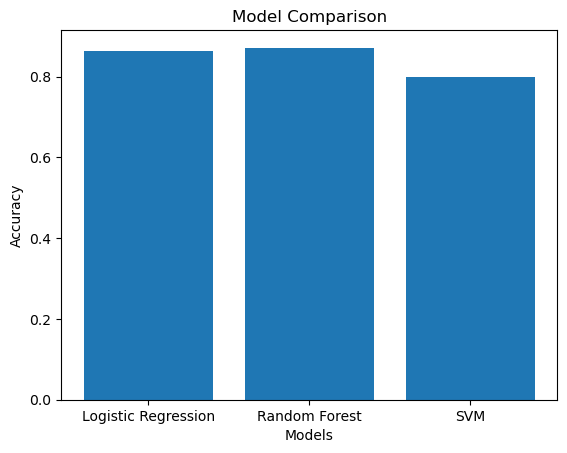

In [70]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest", "SVM"]
accuracy = [0.8635, 0.8717, 0.8001]

plt.figure()
plt.bar(models, accuracy)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")

# SAVE HERE 
plt.savefig("../results/bar_graph.png")

plt.show()

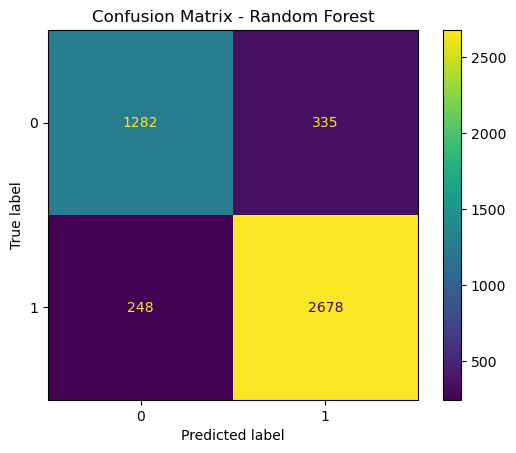

In [71]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_combined, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Random Forest")

# SAVE HERE 
plt.savefig("../results/confusion_matrix_rf.png")

plt.show()

In [2]:
import numpy as np

# GE
X_ge_train = np.load("../data/processed/GE_train_encoded.npy")
y_ge_train = np.load("../data/processed/GE_train_labels.npy")

X_ge_test = np.load("../data/processed/GE_test_encoded.npy")
y_ge_test = np.load("../data/processed/GE_test_labels.npy")

# DM
X_dm_train = np.load("../data/processed/DM_train_encoded.npy")
y_dm_train = np.load("../data/processed/DM_train_labels.npy")

X_dm_test = np.load("../data/processed/DM_test_encoded.npy")
y_dm_test = np.load("../data/processed/DM_test_labels.npy")

In [3]:
X_train_combined = []
y_train_combined = []

for i in range(len(X_ge_train)):
    for j in range(len(X_dm_train)):
        if y_ge_train[i] == y_dm_train[j]:
            combined = np.concatenate((X_ge_train[i], X_dm_train[j]))
            X_train_combined.append(combined)
            y_train_combined.append(y_ge_train[i])

X_train_combined = np.array(X_train_combined)
y_train_combined = np.array(y_train_combined)

In [4]:
X_test_combined = []
y_test_combined = []

for i in range(len(X_ge_test)):
    for j in range(len(X_dm_test)):
        if y_ge_test[i] == y_dm_test[j]:
            combined = np.concatenate((X_ge_test[i], X_dm_test[j]))
            X_test_combined.append(combined)
            y_test_combined.append(y_ge_test[i])

X_test_combined = np.array(X_test_combined)
y_test_combined = np.array(y_test_combined)

In [5]:
print(X_train_combined.shape)
print(X_test_combined.shape)

(24424, 80)
(4543, 80)


In [6]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 2.0 MB/s eta 0:00:52
   ---------------------------------------- 1.0/101.7 MB 2.1 MB/s eta 0:00:48
    --------------------------------------- 1.8/101.7 MB 2.6 MB/s eta 0:00:39
   - -------------------------------------- 2.6/101.7 MB 2.8 MB/s eta 0:00:36
   - -------------------------------------- 3.7/101.7 MB 3.2 MB/s eta 0:00:31
   - -------------------------------------- 4.7/101.7 MB 3.6 MB/s eta 0:00:28
   -- ------------------------------------- 6.0/101.7 MB 3.9 MB/s eta 0:00:25
   -- ------------------------------------- 7.3/101.7 MB 4.2 MB/s eta 0:00:23
   --- ------------------------------------ 8.4/101.7 MB 4.3 MB/s eta 0:00:22
   --- ------------------------------------ 9.7/101.7 MB 4.5 MB/s eta 0:00:21
   ---- ----------------------------------- 11.3/101.7 MB 4.7 MB/s eta 0:00:20

In [7]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train_combined, y_train_combined)

y_pred_xgb = xgb.predict(X_test_combined)

print("=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test_combined, y_pred_xgb))
print(classification_report(y_test_combined, y_pred_xgb))

C:\Users\Dell\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:54:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost ===
Accuracy: 0.8705701078582434
              precision    recall  f1-score   support

           0       0.85      0.78      0.81      1617
           1       0.88      0.92      0.90      2926

    accuracy                           0.87      4543
   macro avg       0.86      0.85      0.86      4543
weighted avg       0.87      0.87      0.87      4543



In [8]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train_combined, y_train_combined)

y_pred_nb = nb.predict(X_test_combined)

print("=== Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test_combined, y_pred_nb))
print(classification_report(y_test_combined, y_pred_nb))

=== Naive Bayes ===
Accuracy: 0.462029495927801
              precision    recall  f1-score   support

           0       0.40      0.99      0.57      1617
           1       0.96      0.17      0.29      2926

    accuracy                           0.46      4543
   macro avg       0.68      0.58      0.43      4543
weighted avg       0.76      0.46      0.39      4543



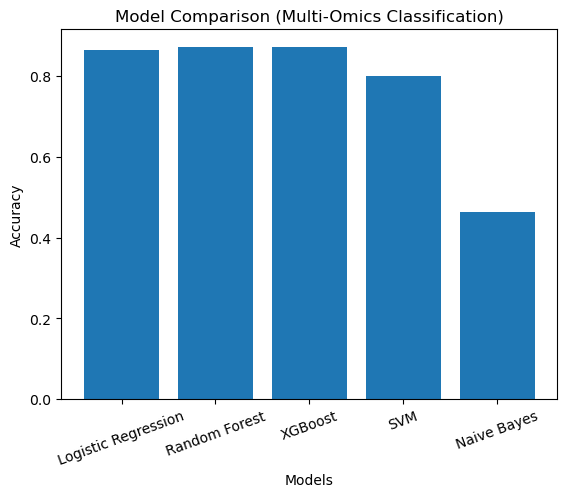

In [13]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost",
    "SVM",
    "Naive Bayes"
]

accuracy = [
    0.8635,
    0.8717,
    0.8706,
    0.8001,
    0.4620
]

plt.figure()

plt.bar(models, accuracy)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison (Multi-Omics Classification)")

plt.xticks(rotation=20)

# Save high-quality image
plt.savefig("../results/final_model_comparison.png", dpi=300)
    

In [15]:
with open("../results/final_results.txt", "a") as f:
    
    f.write("\n\n=== XGBoost (Final - No Leakage) ===\n")
    f.write("Accuracy: 0.8706\n")
    f.write("""
precision    recall  f1-score   support

0       0.85      0.78      0.81      1617
1       0.88      0.92      0.90      2926

accuracy                           0.87      4543
macro avg       0.86      0.85      0.86      4543
weighted avg    0.87      0.87      0.87      4543
""")

    f.write("\n\n=== Naive Bayes (Final - No Leakage) ===\n")
    f.write("Accuracy: 0.4620\n")
    f.write("""
precision    recall  f1-score   support

0       0.40      0.99      0.57      1617
1       0.96      0.17      0.29      2926

accuracy                           0.46      4543
macro avg       0.68      0.58      0.43      4543
weighted avg    0.76      0.46      0.39      4543
""")